In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("Electric_Vehicle_Population_Data.csv")
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EA0K,Thurston,Tumwater,WA,98512.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,22.0,242565116,POINT (-122.91310169999997 47.01359260000004),PUGET SOUND ENERGY INC,5.306701e+10
1,1N4BZ1DV4N,Island,Clinton,WA,98236.0,2022,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,10.0,183272785,POINT (-122.35936399999997 47.97965520000008),PUGET SOUND ENERGY INC,5.302997e+10
2,5YJ3E1EA0L,Snohomish,Snohomish,WA,98290.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,266.0,0.0,44.0,112552366,POINT (-122.09150499999998 47.91555500000004),PUGET SOUND ENERGY INC,5.306105e+10
3,5YJ3E1EBXL,King,Seattle,WA,98134.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,322.0,0.0,11.0,6336319,POINT (-122.32981499999994 47.579810000000066),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
4,5YJSA1CP0D,Snohomish,Edmonds,WA,98020.0,2013,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,69900.0,21.0,186212960,POINT (-122.37507 47.80807000000004),PUGET SOUND ENERGY INC,5.306105e+10


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135038 entries, 0 to 135037
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         135038 non-null  object 
 1   County                                             135030 non-null  object 
 2   City                                               135030 non-null  object 
 3   State                                              135038 non-null  object 
 4   Postal Code                                        135030 non-null  float64
 5   Model Year                                         135038 non-null  int64  
 6   Make                                               135038 non-null  object 
 7   Model                                              134789 non-null  object 
 8   Electric Vehicle Type                              135038 non-null  object

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,135030.000000,135038.000000,135037.000000,135037.000000,134726.000000,1.350380e+05,1.350300e+05
mean,98171.001577,2019.662880,74.591964,1448.407325,29.504379,2.063432e+08,5.297233e+10
std,2450.367211,3.001676,98.744120,9683.658138,14.783780,8.582417e+07,1.635783e+09
min,1730.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.081042e+09
25%,98052.000000,2018.000000,0.000000,0.000000,18.000000,1.606305e+08,5.303301e+10
50%,98121.000000,2021.000000,21.000000,0.000000,34.000000,2.059563e+08,5.303303e+10
75%,98370.000000,2022.000000,150.000000,0.000000,43.000000,2.308888e+08,5.305307e+10
max,99701.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


In [4]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 8
City                                                   8
State                                                  0
Postal Code                                            8
Model Year                                             0
Make                                                   0
Model                                                249
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         1
Base MSRP                                              1
Legislative District                                 312
DOL Vehicle ID                                         0
Vehicle Location                                      10
Electric Utility                                       8
2020 Census Tract                                      8
dtype: int64

Columns with high missing values (Model, Legislative District) are either removed or filled.
Columns with very low missing values are handled using dropna or simple imputation.

In [12]:
df_clean = df.copy()

In [13]:
df_clean.isnull().sum()

VIN (1-10)                                             0
County                                                 8
City                                                   8
State                                                  0
Postal Code                                            8
Model Year                                             0
Make                                                   0
Model                                                249
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         1
Base MSRP                                              1
Legislative District                                 312
DOL Vehicle ID                                         0
Vehicle Location                                      10
Electric Utility                                       8
2020 Census Tract                                      8
dtype: int64

In [14]:
df_clean['Model'] = df_clean['Model'].fillna('Unknown')

df_clean['Legislative District'] = df_clean['Legislative District'].fillna(
    df_clean['Legislative District'].mode()[0]
)

In [15]:
df_clean['Electric Range'] = df_clean['Electric Range'].fillna(
    df_clean['Electric Range'].median()
)

df_clean['Base MSRP'] = df_clean['Base MSRP'].fillna(
    df_clean['Base MSRP'].median()
)

In [16]:
cat_cols = [
    'County', 'City', 'Postal Code',
    'Vehicle Location', 'Electric Utility',
    '2020 Census Tract'
]

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [17]:
df_clean.drop_duplicates(inplace=True)

In [18]:
df_clean.isnull().sum()
df_clean.shape
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135038 entries, 0 to 135037
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         135038 non-null  object 
 1   County                                             135038 non-null  object 
 2   City                                               135038 non-null  object 
 3   State                                              135038 non-null  object 
 4   Postal Code                                        135038 non-null  float64
 5   Model Year                                         135038 non-null  int64  
 6   Make                                               135038 non-null  object 
 7   Model                                              135038 non-null  object 
 8   Electric Vehicle Type                              135038 non-null  object

In [19]:
df_clean.describe()
df_clean.nunique()

VIN (1-10)                                             9059
County                                                  169
City                                                    651
State                                                    46
Postal Code                                             786
Model Year                                               22
Make                                                     36
Model                                                   126
Electric Vehicle Type                                     2
Clean Alternative Fuel Vehicle (CAFV) Eligibility         3
Electric Range                                          102
Base MSRP                                                31
Legislative District                                     49
DOL Vehicle ID                                       135038
Vehicle Location                                        785
Electric Utility                                         76
2020 Census Tract                       

In [28]:
df_clean.isnull().sum()

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64

In [29]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135038 entries, 0 to 135037
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         135038 non-null  object 
 1   County                                             135038 non-null  object 
 2   City                                               135038 non-null  object 
 3   State                                              135038 non-null  object 
 4   Postal Code                                        135038 non-null  float64
 5   Model Year                                         135038 non-null  int64  
 6   Make                                               135038 non-null  object 
 7   Model                                              135038 non-null  object 
 8   Electric Vehicle Type                              135038 non-null  object

In [30]:
df_clean.shape

(135038, 17)

In [31]:
df_clean.duplicated().sum()

np.int64(0)

In [32]:
df_clean.drop_duplicates(inplace=True)

In [33]:
df_clean.nunique()

VIN (1-10)                                             9059
County                                                  169
City                                                    651
State                                                    46
Postal Code                                             786
Model Year                                               22
Make                                                     36
Model                                                   126
Electric Vehicle Type                                     2
Clean Alternative Fuel Vehicle (CAFV) Eligibility         3
Electric Range                                          102
Base MSRP                                                31
Legislative District                                     49
DOL Vehicle ID                                       135038
Vehicle Location                                        785
Electric Utility                                         76
2020 Census Tract                       

In [34]:
df_clean.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,135038.000000,135038.000000,135038.000000,135038.000000,135038.000000,1.350380e+05,1.350380e+05
mean,98170.994527,2019.662880,74.591567,1448.396599,29.530939,2.063432e+08,5.297233e+10
std,2450.294798,3.001676,98.743862,9683.623084,14.777002,8.582417e+07,1.635735e+09
min,1730.000000,1997.000000,0.000000,0.000000,1.000000,4.385000e+03,1.081042e+09
25%,98052.000000,2018.000000,0.000000,0.000000,18.000000,1.606305e+08,5.303301e+10
50%,98121.000000,2021.000000,21.000000,0.000000,34.000000,2.059563e+08,5.303303e+10
75%,98370.000000,2022.000000,150.000000,0.000000,43.000000,2.308888e+08,5.305307e+10
max,99701.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10


The dataset shows that electric range varies widely from 0 to 337 miles, with most vehicles having relatively low range. Base MSRP contains extreme outliers, with many zero values and a few very high luxury values. Model year distribution indicates a strong increase in EV adoption after 2018. The dataset is geographically concentrated in Washington state.

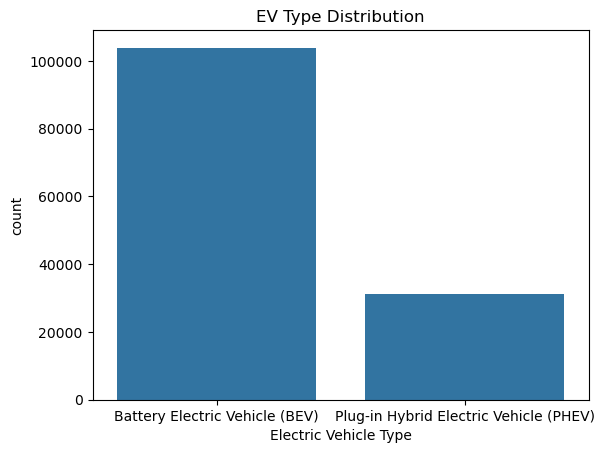

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Electric Vehicle Type', data=df_clean)
plt.title("EV Type Distribution")
plt.show()

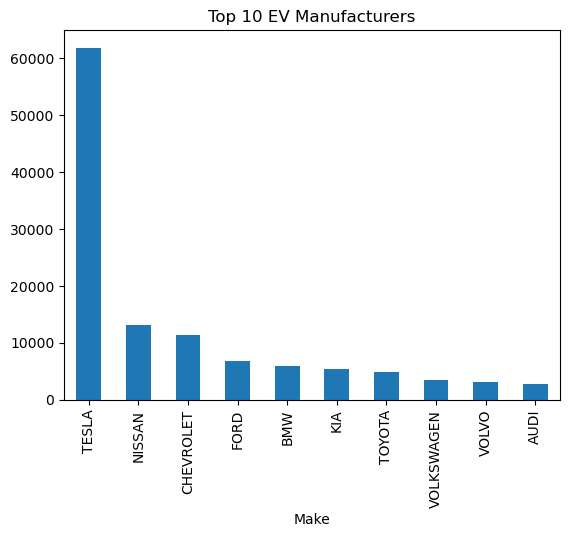

In [38]:
df_clean['Make'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 EV Manufacturers")
plt.show()

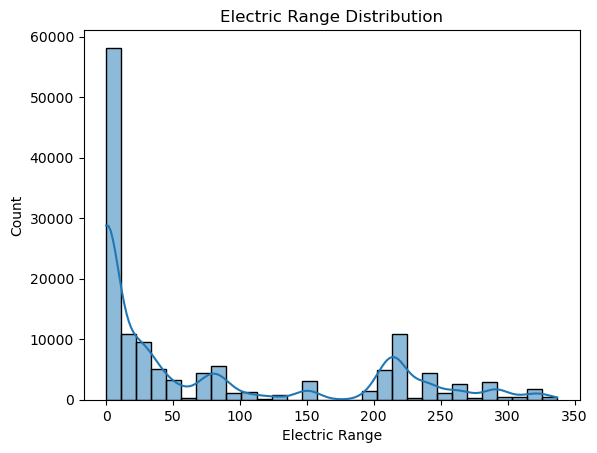

In [39]:
sns.histplot(df_clean['Electric Range'], bins=30, kde=True)
plt.title("Electric Range Distribution")
plt.show()

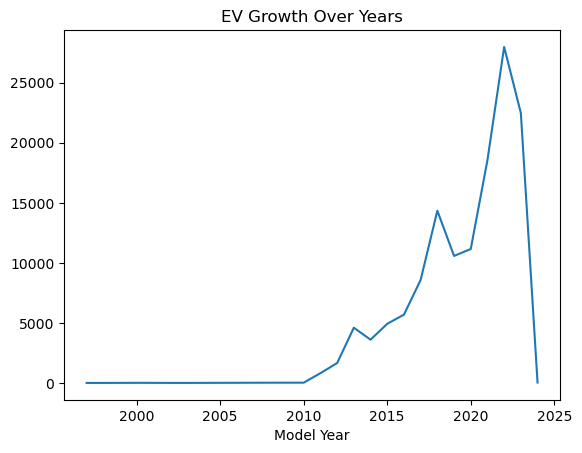

In [41]:
df_clean['Model Year'].value_counts().sort_index().plot(kind='line')
plt.title("EV Growth Over Years")
plt.show()

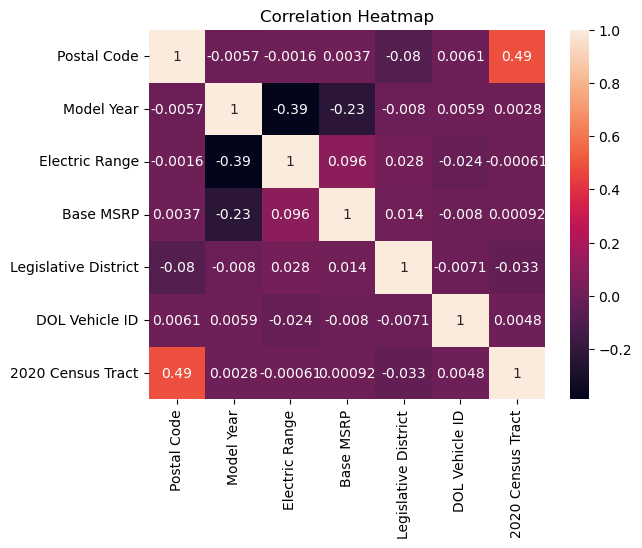

In [42]:
sns.heatmap(df_clean.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()